In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = CNN().to(device)

In [22]:
checkpoint = torch.load(
    "cat_dog_checkpoint (1).pth",
     map_location=device
)

In [23]:
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Modèle chargé avec succès !")
print("Epoch :", checkpoint["epoch"])
print("Val Accuracy :", checkpoint["val_accuracy"])

Modèle chargé avec succès !
Epoch : 49
Val Accuracy : 91.4


Device : cpu
Classes : ['Cat', 'Dog']
Nombre d'images : 5000

Matrice de confusion :
[[2261  239]
 [ 191 2309]]


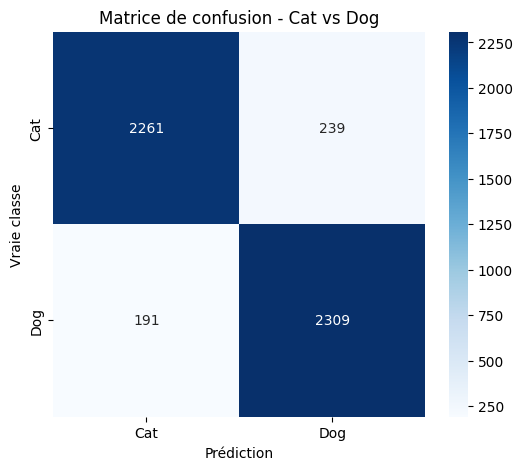


Classification Report :
              precision    recall  f1-score   support

         Cat       0.92      0.90      0.91      2500
         Dog       0.91      0.92      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)




transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])




test_dataset = datasets.ImageFolder(
    "test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Classes :", test_dataset.classes)
print("Nombre d'images :", len(test_dataset))







all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())




cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nMatrice de confusion :")
print(cm)




plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion - Cat vs Dog")

plt.show()



print("\nClassification Report :")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)